In [1]:
import importlib
import pickle
import numpy as np
import matplotlib.pyplot as plt
# --
# import _004_PRC_interaction_chains
# importlib.reload(_004_PRC_interaction_chains)
# from _004_PRC_interaction_chains import generate_transition_matrix_from_categorized
# --
import _010_PRC_extended_interaction_chains
importlib.reload(_010_PRC_extended_interaction_chains)
from _010_PRC_extended_interaction_chains import generate_transition_matrix, parallel_memory_categorization
# --
import _007_EXP_model_validation
importlib.reload(_007_EXP_model_validation)
from _007_EXP_model_validation import get_mm_empirical_distribution, get_md_empiricial_distribution, plot_side_by_side_histograms
# --

In [ ]:
lengths = [10, 30, 50, 100, 200, 300]
amounts = [10, 100, 1000, 10000]

In [ ]:
# generate memory interaction transition matrices from less data

with open("data/categorized/mem-with-0.1init/interactionsmem-window32-p0.1-150-180-100ns.pickle", "rb") as f:
        orig_categorized = pickle.load(f)

for series_len in lengths:
    for n_molecules in amounts:
        print(f"processing series_len: {series_len}, n_molecules: {n_molecules}")
        # randomly choose n_molecules indices from 12500
        indices = np.random.choice(12500, n_molecules, replace=False)
        categorized_trajectories = orig_categorized[indices, -series_len:]
        
        tm, states = generate_transition_matrix(categorized_trajectories,
                                        fg_types=['Nup2', 'Nsp1', 'Nup100', 'Nup116', 'Nup159', 'Nup49', 'Nup57', 'Nup145', 'Nup1', 'Nup60'],
                                        n_chains_per_fg=[16, 48, 16, 16, 16, 32, 32, 16, 8, 16],
                                        init_1 = True,
                                        symmetrize = True,
                                        add_to_diag = 0)
        
        with open(f"data/transition_matrices/less-data-mem/interactions-{int(series_len/10)}us-{n_molecules}n.pickle", "wb") as f:
            pickle.dump((tm, states), f)

processing series_len: 10, n_molecules: 10
processing series_len: 10, n_molecules: 100
processing series_len: 10, n_molecules: 1000
processing series_len: 10, n_molecules: 10000
processing series_len: 30, n_molecules: 10
processing series_len: 30, n_molecules: 100
processing series_len: 30, n_molecules: 1000
processing series_len: 30, n_molecules: 10000
processing series_len: 50, n_molecules: 10
processing series_len: 50, n_molecules: 100
processing series_len: 50, n_molecules: 1000
processing series_len: 50, n_molecules: 10000
processing series_len: 100, n_molecules: 10
processing series_len: 100, n_molecules: 100
processing series_len: 100, n_molecules: 1000
processing series_len: 100, n_molecules: 10000
processing series_len: 200, n_molecules: 10
processing series_len: 200, n_molecules: 100
processing series_len: 200, n_molecules: 1000
processing series_len: 200, n_molecules: 10000
processing series_len: 300, n_molecules: 10
processing series_len: 300, n_molecules: 100
processing se

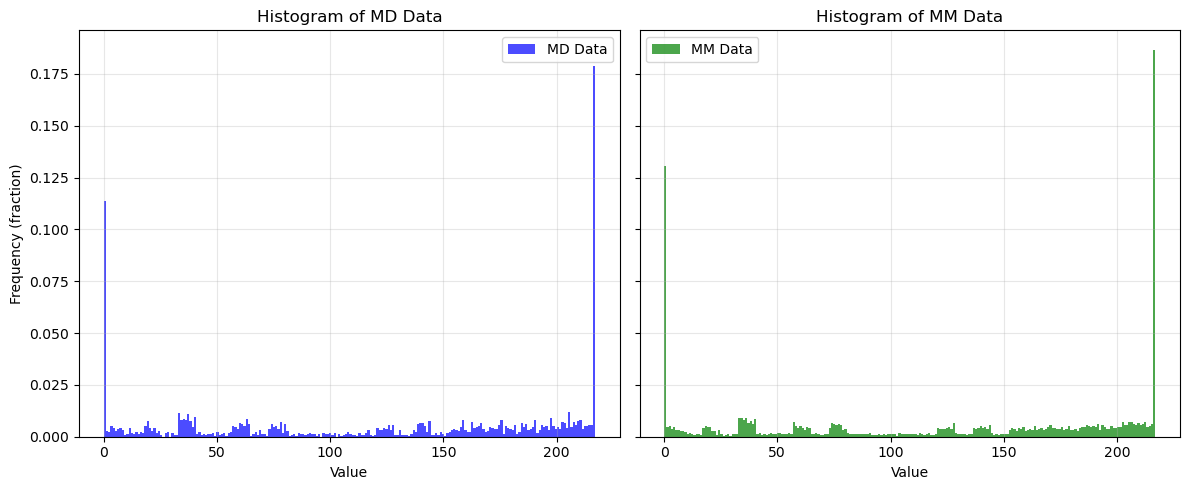

In [18]:
a = get_md_empiricial_distribution(traj_path='data/categorized/interactions-150-180-100ns.pickle',
                                         n_series=1000,
                                         series_len=10)

b = get_md_empiricial_distribution(traj_path='data/categorized/interactions-150-180-100ns.pickle',
                                         n_series=1000,
                                         series_len=300)


plot_side_by_side_histograms(a, b, bins=218, labels=('MD Data', 'MM Data'), titles=('Histogram of MD Data', 'Histogram of MM Data'), figsize=(12, 5))

In [18]:
best = get_md_empiricial_distribution(traj_path='data/categorized/interactions-150-180-100ns.pickle',
                                         n_series=10000,
                                         series_len=300)

from scipy.stats import entropy

def kl_divergence(hist1, hist2, eps=1e-10):
    """Calculate KL divergence between two histograms"""
    # Add small epsilon to avoid division by zero
    p = hist1 + eps
    q = hist2 + eps
    
    # Normalize if not already normalized
    p = p / np.sum(p)
    q = q / np.sum(q)
    
    return entropy(p, q)

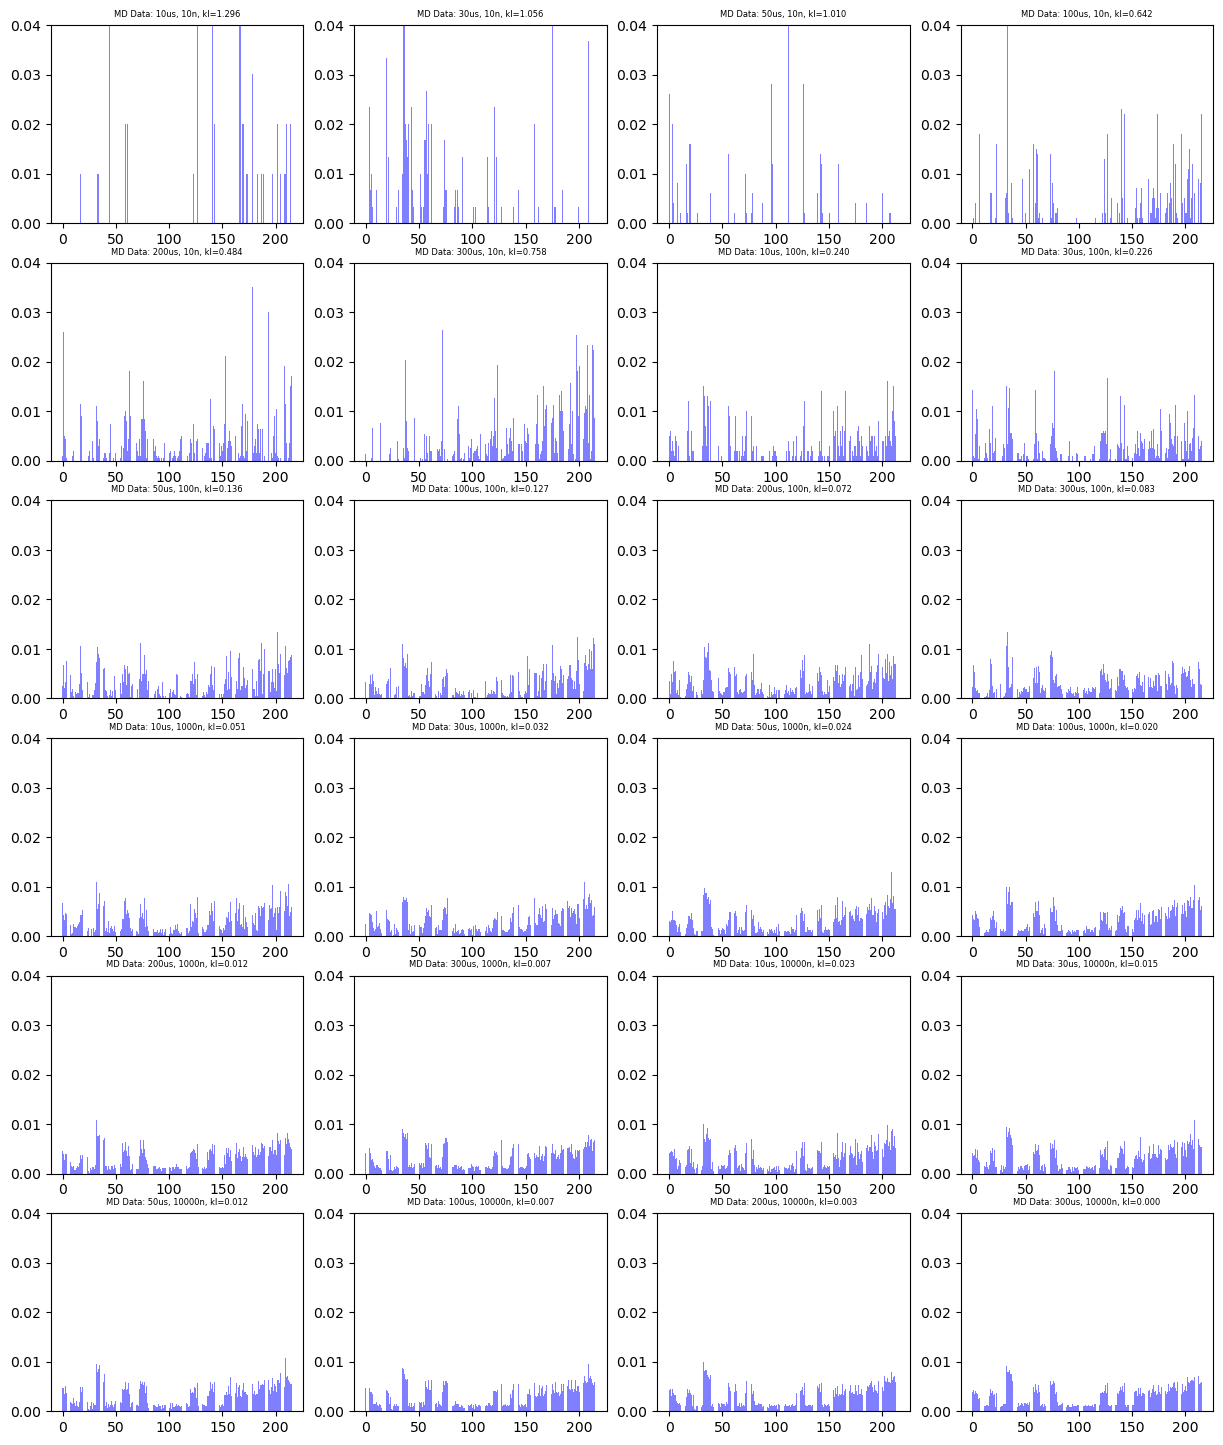

In [20]:
from tkinter import font


plt.figure(figsize=(15, 18))
for i, series_len in enumerate(lengths):
    for j, n_molecules in enumerate(amounts):
        plt.subplot(6, 4, i+1 + j*6)
        
        a = get_md_empiricial_distribution(traj_path='data/categorized/interactions-150-180-100ns.pickle',
                                         n_series=n_molecules,
                                         series_len=series_len)
        kld = kl_divergence(a, best)
        a = a[1:-1]
        
        plt.bar(range(216), a, alpha=0.5, label='MD Data', color='blue')
        plt.ylim(0, 0.04)
        plt.title(f"MD Data: {series_len}us, {n_molecules}n, kl={kld:.3f}", fontsize=6)
plt.show()


In [ ]:
for i, series_len in enumerate(lengths):
    for j, n_molecules in enumerate(amounts):
        print(f"processing series_len: {series_len}, n_molecules: {n_molecules}")        
        a = get_md_empiricial_distribution(traj_path='data/categorized/interactions-150-180-100ns.pickle',
                                         n_series=n_molecules,
                                         series_len=series_len)
        def count_values(series):
            return np.bincount(series, minlength=218)# This gives counts for values 0 to 217

        a = np.append(a, np.zeros(218))
        a = a / np.sum(a)
        
        b = get_mm_empirical_distribution(tm_path=f"data/transition_matrices/less-data-mem/interactions-{int(series_len/10)}us-{n_molecules}n",
                                          n_series=10000,
                                          series_len=300,
                                          mem=True,
                                          init_dist=a)
        
        with open(f"data/empirical_dists/mm-interactions-{int(series_len/10)}us-{n_molecules}n.pickle", "wb") as f:
            pickle.dump(b, f)
        

processing series_len: 10, n_molecules: 10
processing series_len: 10, n_molecules: 100
processing series_len: 10, n_molecules: 1000
processing series_len: 10, n_molecules: 10000
processing series_len: 30, n_molecules: 10
processing series_len: 30, n_molecules: 100
processing series_len: 30, n_molecules: 1000
processing series_len: 30, n_molecules: 10000
processing series_len: 50, n_molecules: 10
processing series_len: 50, n_molecules: 100
processing series_len: 50, n_molecules: 1000
processing series_len: 50, n_molecules: 10000
processing series_len: 100, n_molecules: 10
processing series_len: 100, n_molecules: 100
processing series_len: 100, n_molecules: 1000
processing series_len: 100, n_molecules: 10000
processing series_len: 200, n_molecules: 10
processing series_len: 200, n_molecules: 100
processing series_len: 200, n_molecules: 1000
processing series_len: 200, n_molecules: 10000
processing series_len: 300, n_molecules: 10
processing series_len: 300, n_molecules: 100
processing se

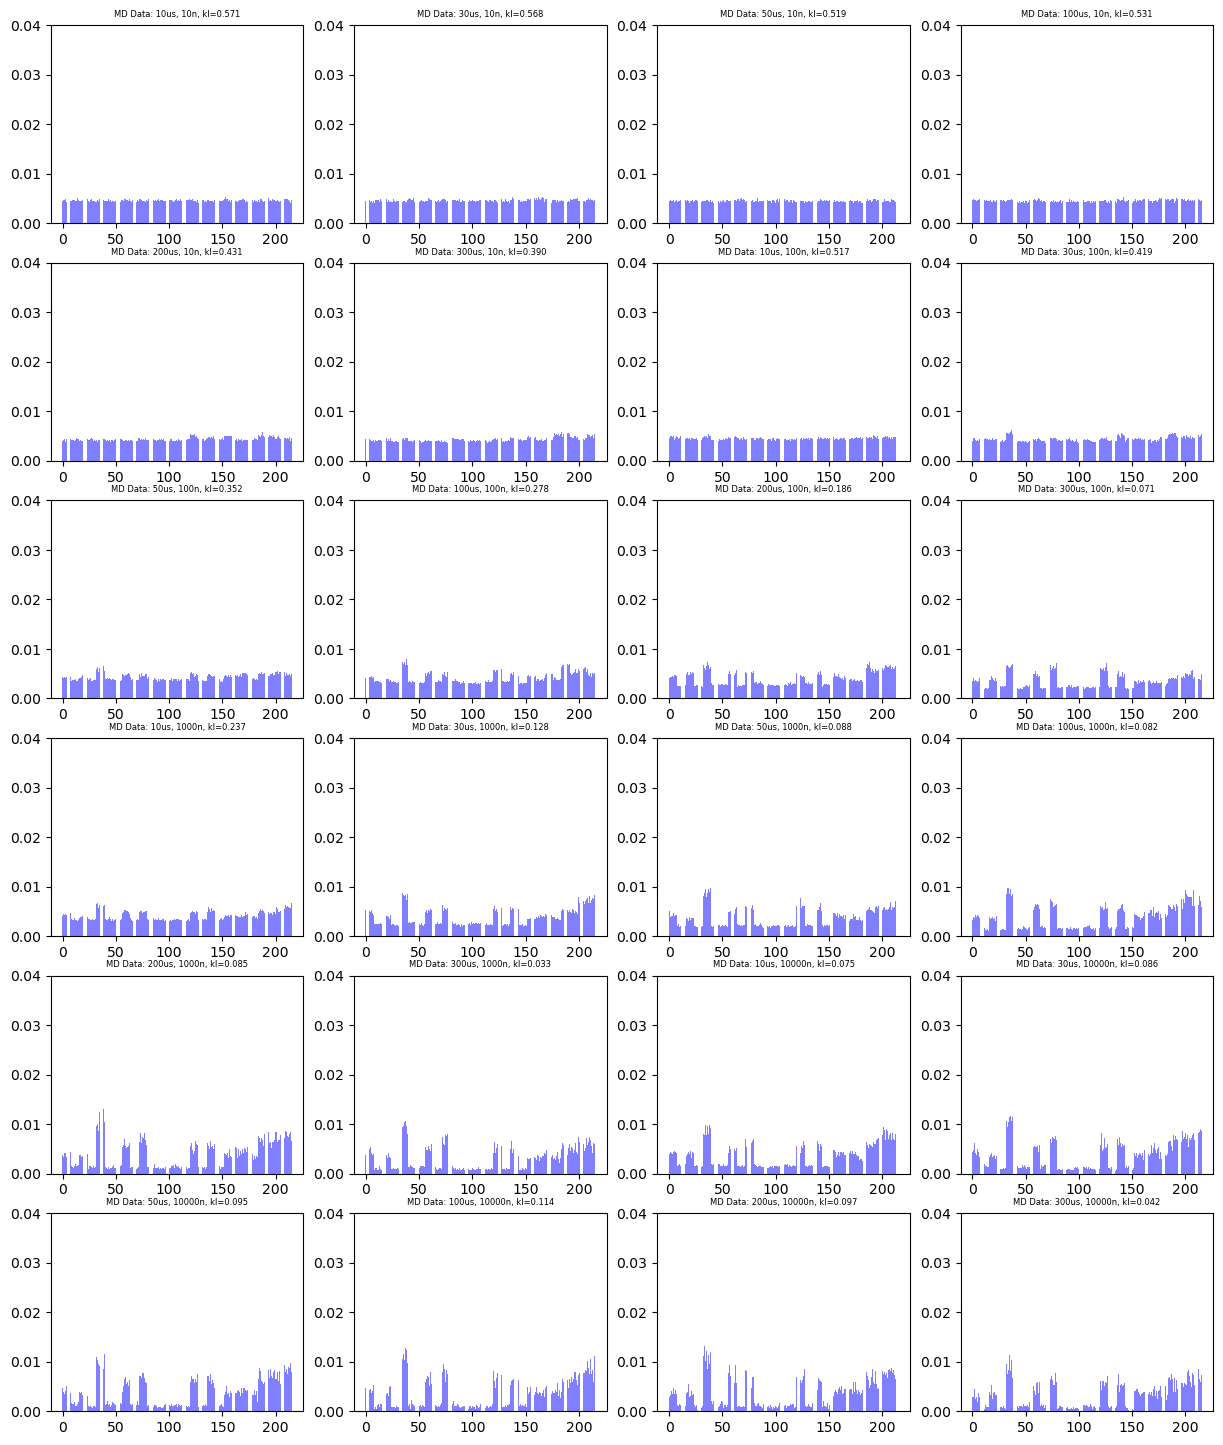

In [21]:
plt.figure(figsize=(15, 18))
for i, series_len in enumerate(lengths):
    for j, n_molecules in enumerate(amounts):
        plt.subplot(6, 4, i+1 + j*6)
        
        with open(f"data/empirical_dists/mm-interactions-{int(series_len/10)}us-{n_molecules}n", "rb") as f:
            b = pickle.load(f)
        kld = kl_divergence(b, best)
        b = b[1:-1]
        
        plt.bar(range(216), b, alpha=0.5, label='MD Data', color='blue')
        plt.ylim(0, 0.04)
        plt.title(f"MD Data: {series_len}us, {n_molecules}n, kl={kld:.3f}", fontsize=6)
plt.show()